In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import os

# Make sure the output directory exists
os.makedirs("data/processed", exist_ok=True)
os.makedirs("images", exist_ok=True)

print("GeoPandas version:", gpd.__version__)

GeoPandas version: 1.1.4


In [4]:
# Load the data
neighborhoods = gpd.read_file(r"C:\Users\vicbfz8\OneDrive - Department of Energy, Environment and Climate Action\Trainings\SpatialLab\Potfolio Project 2\starter-repo\data\nyc_neighborhoods.geojson")
hydrants = gpd.read_file(r"C:\Users\vicbfz8\OneDrive - Department of Energy, Environment and Climate Action\Trainings\SpatialLab\Potfolio Project 2\starter-repo\data\nyc_hydrants.geojson")

print("Neighborhoods:", neighborhoods.shape, "| CRS:", neighborhoods.crs)
print("Hydrants:     ", hydrants.shape,     "| CRS:", hydrants.crs)

Neighborhoods: (262, 12) | CRS: EPSG:4326
Hydrants:      (109725, 8) | CRS: EPSG:4326


In [7]:
# Query 1: Filter
# Sanity check that the data loaded. Pull all neighborhoods in Manhattan.
manhattan = neighborhoods[neighborhoods["boroname"] == "Manhattan"]
manhattan[["ntaname", "boroname"]].head(10)

,ntaname,boroname
118,Financial District-Battery Park City,Manhattan
119,Tribeca-Civic Center,Manhattan
120,The Battery-Governors Island-Ellis Island-Libe...,Manhattan
121,SoHo-Little Italy-Hudson Square,Manhattan
122,Greenwich Village,Manhattan
123,West Village,Manhattan
124,Chinatown-Two Bridges,Manhattan
125,Lower East Side,Manhattan
126,East Village,Manhattan
127,Chelsea-Hudson Yards,Manhattan


In [10]:
# Query 2: Spatial join
# Match each hydrant to the neighborhood that contains it. Equivalent of `JOIN ... ON ST_Contains(n.geom, h.geom)`.

# Predicate: "within" (hydrant within neighborhood)
# Suggested: how="left" so unmatched hydrants are preserved (you can count them later)
joined = gpd.sjoin(hydrants, neighborhoods, predicate="within", how="left")

print(f"Joined rows: {len(joined):,}")
joined.head()

Joined rows: 109,725


,cb,latitude,unitid,point_y,longitude,point_x,boro,geometry,index_right,shape_area,ntaname,cdtaname,shape_leng,boroname,ntatype,nta2020,borocode,countyfips,ntaabbrev,cdta2020
0,407,40.7722168,H425919a,220683.273,-73.79457092,1041150.586,4,POINT (-73.79457 40.77222),210.0,55464055.3177,Auburndale,QN11 Auburndale-Bayside-Douglaston (CD 11 Appr...,39268.992231,Queens,0,QN1101,4,081,Abrndl,QN11
1,318,40.64434814,H325449,174041.245,-73.9128952,1008423.396,3,POINT (-73.91289 40.64435),61.0,70533384.3877,Canarsie,BK18 Canarsie-Flatlands (CD 18 Approximation),43865.6761035,Brooklyn,0,BK1803,3,047,Cnrsie,BK18
2,301,40.72505569,H307276,203437.906,-73.95304108,997266.219,3,POINT (-73.95304 40.72506),0.0,35321808.4385,Greenpoint,BK01 Williamsburg-Greenpoint (CD 1 Equivalent),28919.5607283,Brooklyn,0,BK0101,3,047,Grnpt,BK01
3,302,40.6939888,H301843,192115.373,-73.99462891,985738.421,3,POINT (-73.99463 40.69399),4.0,9982022.78507,Brooklyn Heights,BK02 Downtown Brooklyn-Fort Greene (CD 2 Appro...,14312.1924247,Brooklyn,0,BK0201,3,047,BkHts,BK02
4,402,40.73529053,H439410,207168.6435,-73.93569183,1002071.97,4,POINT (-73.93569 40.73529),166.0,47701718.3248,Sunnyside,QN02 Long Island City-Sunnyside-Woodside (CD 2...,34952.1551097,Queens,0,QN0202,4,081,Snnysd,QN02


In [12]:
# Query 3: Aggregate
# Count hydrants per neighborhood. Equivalent of `GROUP BY neighborhood ... COUNT(*)`.

counts = (
    joined.groupby("ntaname").size().rename("hydrant_count").to_frame()
)
counts.sort_values("hydrant_count", ascending=False).head(10)


,hydrant_count
ntaname,
Annadale-Huguenot-Prince's Bay-Woodrow,1708
Great Kills-Eltingville,1672
Todt Hill-Emerson Hill-Lighthouse Hill-Manor Heights,1282
Sheepshead Bay-Manhattan Beach-Gerritsen Beach,1187
Canarsie,1155
Westerleigh-Castleton Corners,1137
New Springville-Willowbrook-Bulls Head-Travis,1111
West New Brighton-Silver Lake-Grymes Hill,1103
Bay Ridge,1096


In [13]:
# Query 4: Normalize (the headline)
# Reproject to EPSG:2263 (NY State Plane Long Island, feet) to compute area in real units. Convert square feet to square kilometers, then density per km².

# Merge counts back onto neighborhoods, then compute density.
SQ_FT_PER_KM2 = 10_763_910.42

result = neighborhoods.merge(counts, on="ntaname", how="left").fillna({"hydrant_count": 0})
result["area_km2"] = result.to_crs(2263).area / SQ_FT_PER_KM2
result["density_per_km2"] = result["hydrant_count"] / result["area_km2"]

result.sort_values("density_per_km2", ascending=False)[
    ["ntaname", "boroname", "hydrant_count", "area_km2", "density_per_km2"]
].head(10)

,ntaname,boroname,hydrant_count,area_km2,density_per_km2
132,Gramercy,Manhattan,269.0,0.699191,384.730533
121,SoHo-Little Italy-Hudson Square,Manhattan,432.0,1.200010,359.996983
119,Tribeca-Civic Center,Manhattan,433.0,1.261464,343.251854
123,West Village,Manhattan,447.0,1.339374,333.737919
118,Financial District-Battery Park City,Manhattan,570.0,1.786227,319.108289
122,Greenwich Village,Manhattan,304.0,0.985047,308.614624
140,Upper East Side-Carnegie Hill,Manhattan,565.0,1.864132,303.090174
126,East Village,Manhattan,522.0,1.763505,296.001395
130,Midtown-Times Square,Manhattan,669.0,2.281004,293.291889
124,Chinatown-Two Bridges,Manhattan,310.0,1.072234,289.116065


In [16]:
# Query 5: Coverage analysis
# What percent of each neighborhood is within 100 meters of a hydrant?
# This is the deeper finding. The headline (Query 4) tells you where coverage is densest. This tells you how complete coverage is across each neighborhood, regardless of count.

# 1) Buffer every hydrant by 100 meters (after reprojecting to 2263)
# 2) Compute the union of all those buffers
hydrants_2263 = hydrants.to_crs(2263)
hydrant_coverage = hydrants_2263.buffer(328.084).union_all()

# 3) Intersect each neighborhood with the union and divide by neighborhood area.
result_2263 = result.to_crs(2263).copy()
result_2263["covered_area"] = result_2263.geometry.intersection(hydrant_coverage).area
result_2263["covered_pct"] = result_2263["covered_area"] / result_2263.geometry.area

result_2263[["ntaname", "boroname", "covered_pct"]].sort_values(
    "covered_pct", ascending=False
).head(10)

,ntaname,boroname,covered_pct
11,Bushwick (West),Brooklyn,1.0
52,Ocean Hill,Brooklyn,1.0
205,Woodhaven,Queens,1.0
80,Mount Eden-Claremont (West),Bronx,1.0
140,Upper East Side-Carnegie Hill,Manhattan,1.0
53,Brownsville,Brooklyn,1.0
49,Gravesend (East)-Homecrest,Brooklyn,1.0
122,Greenwich Village,Manhattan,1.0
26,Prospect Heights,Brooklyn,1.0
47,Flatbush (West)-Ditmas Park-Parkville,Brooklyn,1.0


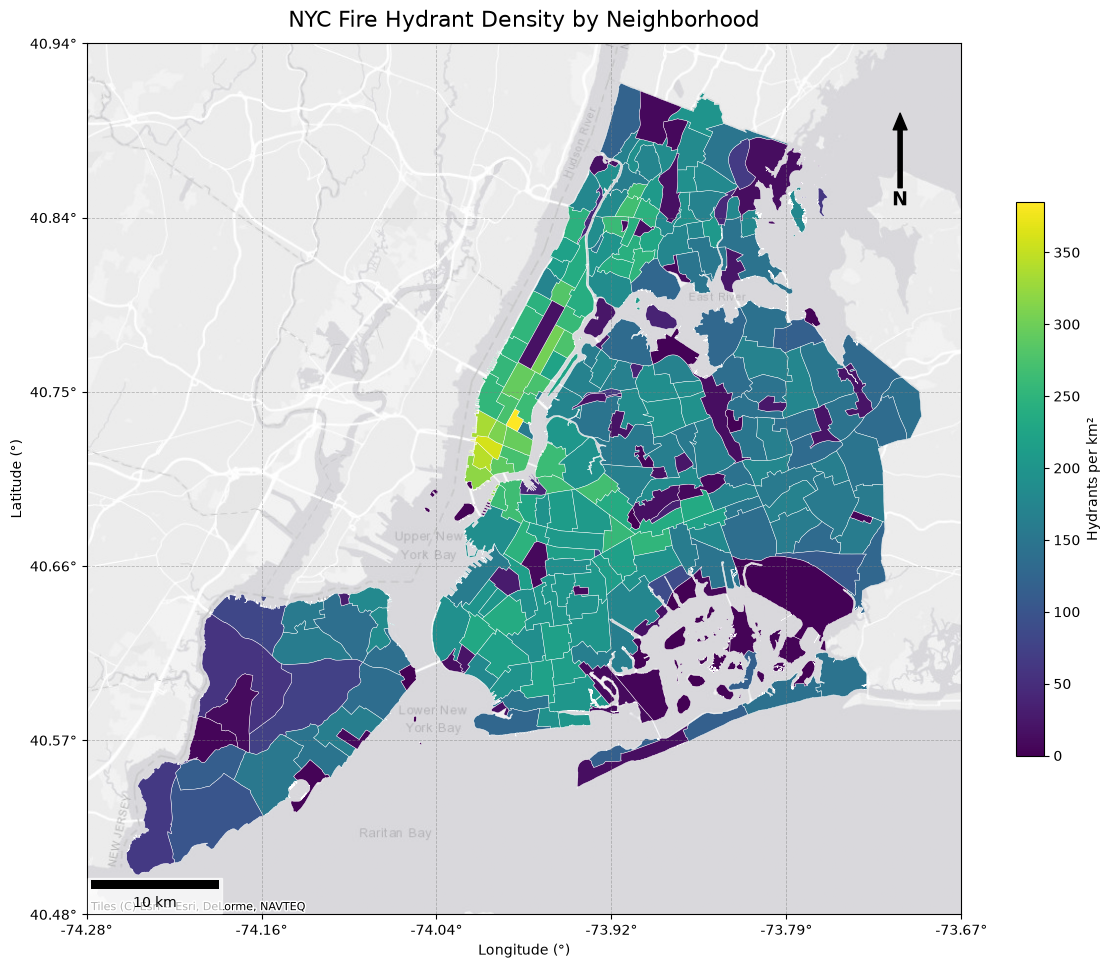

In [23]:
# Visualize: static choropleth

import contextily as ctx
from matplotlib_scalebar.scalebar import ScaleBar
from pyproj import Transformer
import numpy as np

result_3857 = result.to_crs(3857)

fig, ax = plt.subplots(figsize=(12, 10))

# Choropleth
result_3857.plot(
    column="density_per_km2",
    cmap="viridis",
    legend=True,
    edgecolor="white",
    linewidth=0.3,
    ax=ax,
    legend_kwds={"label": "Hydrants per km²", "shrink": 0.6},
)

# ESRI Light Grey basemap
ctx.add_basemap(
    ax,
    source=ctx.providers.Esri.WorldGrayCanvas,
    crs=result_3857.crs,
    alpha=0.8
)

# ------------------------------------------------------------------
# Convert Mercator ticks to geographic degrees
# ------------------------------------------------------------------

transformer = Transformer.from_crs(
    "EPSG:3857",
    "EPSG:4326",
    always_xy=True
)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()

xticks = np.linspace(xmin, xmax, 6)
yticks = np.linspace(ymin, ymax, 6)

ax.set_xticks(xticks)
ax.set_yticks(yticks)

lon_labels = [
    f"{transformer.transform(x, ymin)[0]:.2f}°"
    for x in xticks
]

lat_labels = [
    f"{transformer.transform(xmin, y)[1]:.2f}°"
    for y in yticks
]

ax.set_xticklabels(lon_labels)
ax.set_yticklabels(lat_labels)

# Grid
ax.grid(
    True,
    linestyle="--",
    linewidth=0.6,
    color="grey",
    alpha=0.5
)

# ------------------------------------------------------------------
# Scale bar
# ------------------------------------------------------------------

ax.add_artist(
    ScaleBar(
        dx=1,
        units="m",
        location="lower left",
        length_fraction=0.2,
        box_alpha=0.7
    )
)

# ------------------------------------------------------------------
# North arrow
# ------------------------------------------------------------------

ax.annotate(
    "N",
    xy=(0.93, 0.92),
    xytext=(0.93, 0.82),
    arrowprops=dict(
        facecolor="black",
        width=3,
        headwidth=10
    ),
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    xycoords="axes fraction"
)

ax.set_xlabel("Longitude (°)")
ax.set_ylabel("Latitude (°)")

ax.set_title(
    "NYC Fire Hydrant Density by Neighborhood",
    fontsize=16,
    pad=12
)

plt.tight_layout()
plt.show()